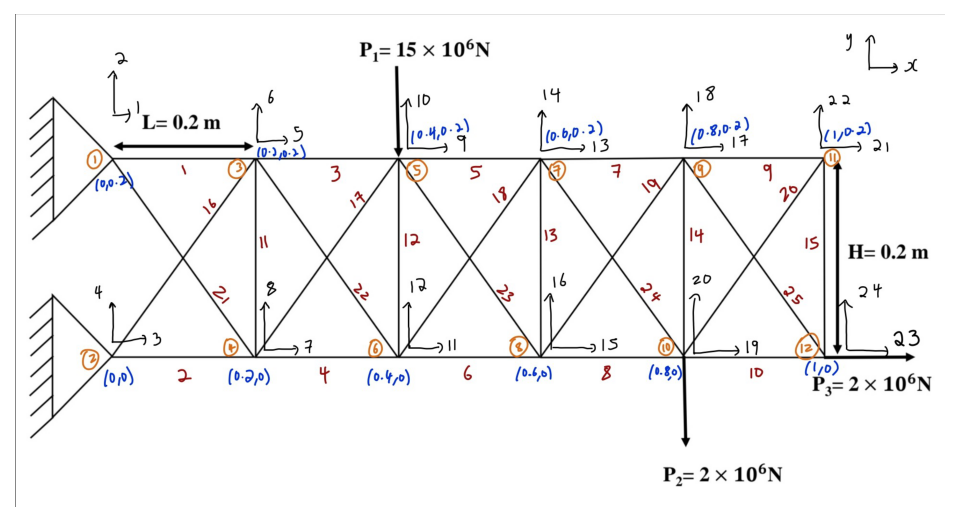

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(r"C:\Users\10H17\Downloads\Question3.jpg")

plt.figure(figsize=(8,6), dpi=150) 
plt.imshow(img)
plt.axis('off')
plt.show()

Importing necessart modules.

In [2]:
import numpy as np
import calfem.core as cfc
import pandas as pd

Defining Topology, element 1 has axis 1,2,5,6 and element 2 has 3,4,7,8 and so on

In [3]:
Edof = np.array([
    [1, 2, 5, 6],
    [3, 4, 7, 8],
    [5, 6, 9, 10],
    [7, 8, 11, 12],
    [9, 10, 13, 14],
    [11, 12, 15, 16],
    [13, 14, 17, 18],
    [15, 16, 19, 20],
    [17, 18, 21, 22],
    [19, 20, 23, 24],
    [7, 8, 5, 6],
    [11, 12, 9, 10],
    [15, 16, 13, 14],
    [19, 20, 17, 18],
    [23, 24, 21, 22],
    [3, 4, 5, 6],
    [7, 8, 9, 10],
    [11, 12, 13, 14],
    [15, 16, 17, 18],
    [19, 20, 21, 22],
    [1, 2, 7, 8],
    [5, 6, 11, 12],
    [9, 10, 15, 16],
    [13, 14, 19, 20],
    [17, 18, 23, 24]
])

Defining K, f matrix size

In [4]:
K = np.zeros([24,24])
f = np.zeros([24,1])

Giving Area and Young's modulus values

In [5]:
A = 0.2
E = 2e11
ep = [E,A]

Global coordinate matrix coord and a global topology matrix Dof is defined

In [6]:
Coord = np.array([
[0, 0.2],
[0,0],
[0.2,0.2],
[0.2,0],
[0.4,0.2],
[0.4,0],
[0.6,0.2],
[0.6,0],
[0.8,0.2],
[0.8,0],
[1,0.2],
[1,0]
])

Dof = np.array([
[1, 2],      # Node 1
[3, 4],      # Node 2
[5, 6],      # Node 3
[7, 8],      # Node 4
[9, 10],     # Node 5
[11, 12],    # Node 6
[13, 14],    # Node 7
[15, 16],    # Node 8
[17, 18],    # Node 9
[19, 20],    # Node 10
[21, 22],    # Node 11
[23, 24]     # Node 12
])
ex, ey = cfc.coordxtr(Edof, Coord, Dof)

Loop is run to assemble the matrices

In [7]:
for elx, ely, eltopo in zip(ex, ey, Edof):
    Ke = cfc.bar2e(elx, ely, ep)
    cfc.assem(eltopo, K, Ke)

Boundary conditions are given

In [8]:
bc = np.array([1,2,3,4])

f[9] = -15e6
f[19] = -2e6
f[22] = 2e6


a, r = cfc.solveq(K,f,bc)

Displacement values at each node

In [9]:
ux = a[0::2].flatten()
uy = a[1::2].flatten()

table = pd.DataFrame({
    "Node": range(1, 13),
    "ux": ux,
    "uy": uy
})

print(table)

    Node        ux        uy
0      1  0.000000  0.000000
1      2  0.000000  0.000000
2      3  0.000146 -0.000262
3      4 -0.000139 -0.000263
4      5  0.000211 -0.000741
5      6 -0.000189 -0.000709
6      7  0.000229 -0.001149
7      8 -0.000191 -0.001150
8      9  0.000232 -0.001583
9     10 -0.000188 -0.001585
10    11  0.000231 -0.001999
11    12 -0.000179 -0.001998


Reaction forces at each node

In [10]:
fx = r[0::2].flatten()
fy = r[1::2].flatten()

table = pd.DataFrame({
    "Node": range(1, 13),
    "fx": fx,
    "fy": fy
})

print(table)

    Node            fx            fy
0      1 -3.800000e+07  8.793776e+06
1      2  3.600000e+07  8.206224e+06
2      3  0.000000e+00  5.587935e-09
3      4  0.000000e+00 -1.117587e-08
4      5  1.490116e-08  5.587935e-09
5      6 -7.450581e-09 -1.490116e-08
6      7 -1.490116e-08 -5.587935e-09
7      8 -7.450581e-09 -7.450581e-09
8      9  1.490116e-08  1.862645e-09
9     10  0.000000e+00  3.166497e-08
10    11 -2.235174e-08 -8.195639e-08
11    12  3.725290e-08  5.215406e-08


Visualising deformation via plot

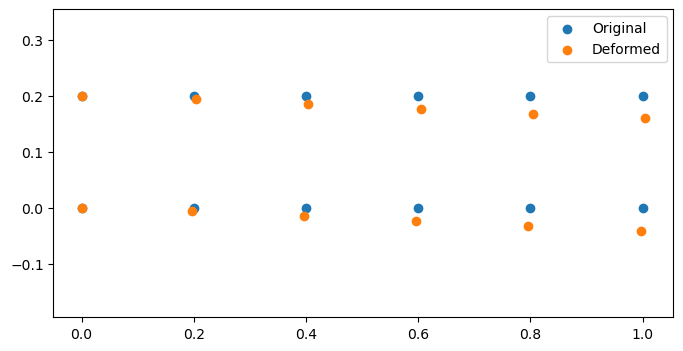

In [14]:
scale = 20

deformed = Coord + scale * np.column_stack((ux, uy))

plt.figure(figsize=(8,4))

plt.scatter(Coord[:,0], Coord[:,1], label="Original")

plt.scatter(deformed[:,0], deformed[:,1], label="Deformed")

plt.legend()
plt.axis("equal")
plt.show()